In [23]:
from pathlib import Path
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras import layers, Model

In [2]:
## Find all Weather.csv files

DATA_ROOT = Path("../data/csv")

weather_files = sorted(DATA_ROOT.glob("*/Weather.csv"))

print(f"Found {len(weather_files)} files\n")

for i, f in enumerate(weather_files):
    print(i, f.parent.name)

Found 3 files

0 Huis_19_06_2026_30min
1 Huis_19_06_2026_all
2 Huis_may_2025


In [3]:
## Loader

def load_weather_file(path):
    df = pd.read_csv(
        path,
        skiprows=5,
        sep=",",
        engine="python"
    )

    df.columns = [str(c).strip() for c in df.columns]

    df = df.rename(columns={
        "Timezone : Europe/Amsterdam": "datetime"
    })

    if "datetime" in df.columns:
        df["datetime"] = pd.to_datetime(df["datetime"])

    return df

In [4]:
## Load data

path = weather_files[2]
df = load_weather_file(path)

print(path.parent.name)
df.head()

Huis_may_2025


,Timestamp,datetime,Temperature °C,Humidity %,CO2 ppm,Noise dB,Pressure Pa,Unnamed: 7,Temperature °C.1,Humidity %.1,Unnamed: 10
0,1745964150,2025-04-30 00:02:30,22.3,52,1168,32,1022.7,NaN,14.1,80.0,NaN
1,1745964450,2025-04-30 00:07:30,22.3,52,1168,32,1022.7,NaN,14.2,80.0,NaN
2,1745964750,2025-04-30 00:12:30,22.2,52,1168,32,1022.7,NaN,14.1,80.0,NaN
3,1745965050,2025-04-30 00:17:30,22.3,52,1141,33,1022.7,NaN,14.1,80.0,NaN
4,1745965350,2025-04-30 00:22:30,22.2,52,1141,34,1022.7,NaN,14.1,81.0,NaN


In [17]:
df = df.rename(columns={
    "Temperature °C": "temp_in",
    "Temperature °C.1": "temp_out",
    "Humidity %.1": "hum_out"
})

df = df[["datetime", "temp_in", "temp_out", "hum_out"]].dropna()

df["hour"] = df["datetime"].dt.hour
df["dayofyear"] = df["datetime"].dt.dayofyear

df["hour_sin"] = np.sin(2*np.pi*df["hour"]/24)
df["hour_cos"] = np.cos(2*np.pi*df["hour"]/24)
df["day_sin"] = np.sin(2*np.pi*df["dayofyear"]/365.25)
df["day_cos"] = np.cos(2*np.pi*df["dayofyear"]/365.25)

In [18]:
feature_columns = [
    "temp_out",
    "hum_out",
    "hour_sin",
    "hour_cos",
    "day_sin",
    "day_cos",
]

target_column = "temp_in"

df = df.dropna().reset_index(drop=True)

X = df[feature_columns]
y = df[target_column]

In [19]:
n = len(df)

train_end = int(0.7*n)
val_end = int(0.85*n)

train_df = df.iloc[:train_end]
val_df = df.iloc[train_end:val_end]
test_df = df.iloc[val_end:]

In [20]:
scaler_x = StandardScaler()
scaler_y = StandardScaler()

X_train = scaler_x.fit_transform(train_df[feature_columns])
X_val = scaler_x.transform(val_df[feature_columns])
X_test = scaler_x.transform(test_df[feature_columns])

y_train = scaler_y.fit_transform(train_df[[target_column]])
y_val = scaler_y.transform(val_df[[target_column]])
y_test = scaler_y.transform(test_df[[target_column]])

In [21]:
def create_sequences(X, y, lookback=48, horizon=12):
    Xs, ys = [], []

    for i in range(len(X) - lookback - horizon):
        Xs.append(X[i:i+lookback])
        ys.append(y[i+lookback:i+lookback+horizon].flatten())

    return np.array(Xs), np.array(ys)

LOOKBACK = 48      # past 4 hours (5-min data)
HORIZON = 12       # next 1 hour

X_train_seq, y_train_seq = create_sequences(X_train, y_train, LOOKBACK, HORIZON)
X_val_seq, y_val_seq = create_sequences(X_val, y_val, LOOKBACK, HORIZON)
X_test_seq, y_test_seq = create_sequences(X_test, y_test, LOOKBACK, HORIZON)

In [24]:
inputs = layers.Input(shape=(LOOKBACK, len(feature_columns)))

x = layers.LSTM(64, return_sequences=True)(inputs)
x = layers.LSTM(32)(x)

x = layers.Dense(64, activation="relu")(x)
outputs = layers.Dense(HORIZON)(x)

lstm_model = Model(inputs, outputs)

lstm_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

lstm_model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 48, 6)]           0         
                                                                 
 lstm (LSTM)                 (None, 48, 64)            18176     
                                                                 
 lstm_1 (LSTM)               (None, 32)                12416     
                                                                 
 dense_3 (Dense)             (None, 64)                2112      
                                                                 
 dense_4 (Dense)             (None, 12)                780       
                                                                 
Total params: 33484 (130.80 KB)
Trainable params: 33484 (130.80 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [25]:
history = lstm_model.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=30,
    batch_size=256,
    verbose=1
)

Epoch 1/30
24/24 [==============================] - 4s 96ms/step - loss: 0.7754 - mae: 0.6901 - val_loss: 1.1823 - val_mae: 0.8864
Epoch 2/30
24/24 [==============================] - 2s 71ms/step - loss: 0.3581 - mae: 0.4552 - val_loss: 1.4373 - val_mae: 0.9973
Epoch 3/30
24/24 [==============================] - 2s 72ms/step - loss: 0.2333 - mae: 0.3614 - val_loss: 1.6146 - val_mae: 1.0922
Epoch 4/30
24/24 [==============================] - 2s 68ms/step - loss: 0.1978 - mae: 0.3318 - val_loss: 1.6281 - val_mae: 1.1172
Epoch 5/30
24/24 [==============================] - 2s 66ms/step - loss: 0.1631 - mae: 0.3002 - val_loss: 1.3548 - val_mae: 0.9685
Epoch 6/30
24/24 [==============================] - 2s 73ms/step - loss: 0.1337 - mae: 0.2744 - val_loss: 1.7495 - val_mae: 1.1490
Epoch 7/30
24/24 [==============================] - 2s 74ms/step - loss: 0.1102 - mae: 0.2474 - val_loss: 2.1197 - val_mae: 1.2919
Epoch 8/30
24/24 [==============================] - 2s 68ms/step - loss: 0.0990 - m

In [26]:
pred = lstm_model.predict(X_test_seq)

y_true = scaler_y.inverse_transform(y_test_seq)
y_pred = scaler_y.inverse_transform(pred)

mae = mean_absolute_error(y_true.flatten(), y_pred.flatten())
rmse = np.sqrt(mean_squared_error(y_true.flatten(), y_pred.flatten()))

print("LSTM MAE:", mae)
print("LSTM RMSE:", rmse)

39/39 [==============================] - 1s 8ms/step
LSTM MAE: 2.302148466410799
LSTM RMSE: 2.431122116307373


In [27]:
def physics_model(temp_in, temp_out, alpha=0.02):
    return temp_in + alpha * (temp_out - temp_in)

In [28]:
phys_preds = []

temp_in = test_df["temp_in"].iloc[0]

for t in range(len(test_df)):
    temp_out = test_df["temp_out"].iloc[t]
    temp_in = physics_model(temp_in, temp_out)
    phys_preds.append(temp_in)

phys_preds = np.array(phys_preds)

In [29]:
physics_train = []

temp_in = train_df["temp_in"].iloc[0]

for t in range(len(train_df)):
    temp_out = train_df["temp_out"].iloc[t]
    temp_in = physics_model(temp_in, temp_out)
    physics_train.append(temp_in)

physics_train = np.array(physics_train)

residual_train = train_df["temp_in"].values - physics_train

In [30]:
res_model = tf.keras.Sequential([
    layers.Dense(32, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(1)
])

res_model.compile(optimizer="adam", loss="mse")

In [31]:
res_model.fit(
    scaler_x.transform(train_df[feature_columns]),
    residual_train,
    epochs=20,
    batch_size=256,
    verbose=1
)

Epoch 1/20
24/24 [==============================] - 0s 1ms/step - loss: 30.4046
Epoch 2/20
24/24 [==============================] - 0s 1ms/step - loss: 21.8438
Epoch 3/20
24/24 [==============================] - 0s 1ms/step - loss: 13.1253
Epoch 4/20
24/24 [==============================] - 0s 1ms/step - loss: 7.8627
Epoch 5/20
24/24 [==============================] - 0s 1ms/step - loss: 5.6969
Epoch 6/20
24/24 [==============================] - 0s 951us/step - loss: 4.2362
Epoch 7/20
24/24 [==============================] - 0s 927us/step - loss: 3.2211
Epoch 8/20
24/24 [==============================] - 0s 1ms/step - loss: 2.5661
Epoch 9/20
24/24 [==============================] - 0s 1ms/step - loss: 2.2333
Epoch 10/20
24/24 [==============================] - 0s 970us/step - loss: 2.0572
Epoch 11/20
24/24 [==============================] - 0s 992us/step - loss: 1.9449
Epoch 12/20
24/24 [==============================] - 0s 945us/step - loss: 1.8473
Epoch 13/20
24/24 [=================

In [32]:
hybrid_preds = []

temp_in = test_df["temp_in"].iloc[0]

X_test_scaled = scaler_x.transform(test_df[feature_columns])

for i in range(len(test_df)):

    phys = physics_model(
        temp_in,
        test_df["temp_out"].iloc[i]
    )

    residual = res_model.predict(X_test_scaled[i:i+1], verbose=0)[0,0]

    temp_in = phys + residual
    hybrid_preds.append(temp_in)

hybrid_preds = np.array(hybrid_preds)

In [33]:
true = test_df["temp_in"].values

def metrics(y_true, y_pred):
    return (
        mean_absolute_error(y_true, y_pred),
        np.sqrt(mean_squared_error(y_true, y_pred))
    )

print("Physics:", metrics(true, phys_preds))
print("Hybrid:", metrics(true, hybrid_preds))

Physics: (4.631703108462341, 5.161292952532955)
Hybrid: (410.9951671983839, 424.7496775859092)


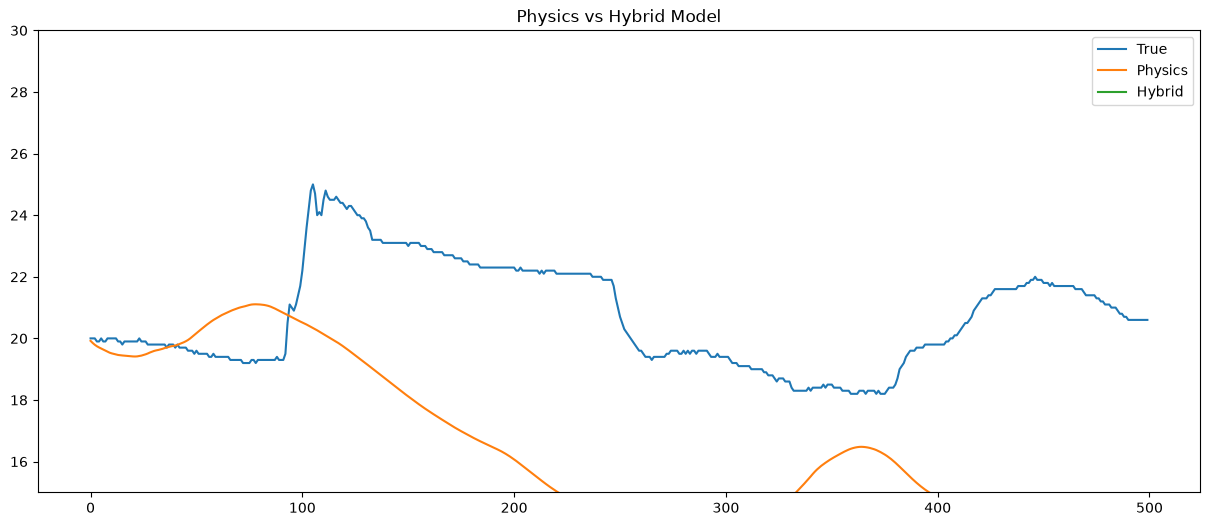

In [35]:
plt.figure(figsize=(15,6))

plt.plot(true[:500], label="True")
plt.plot(phys_preds[:500], label="Physics")
plt.plot(hybrid_preds[:500], label="Hybrid")

plt.legend()
plt.title("Physics vs Hybrid Model")
plt.ylim([15, 30])
plt.show()